# 15 — ECG × Psychosocial & SDOH Factors

**Purpose**: Test whether psychosocial burden (depression, diabetes distress, food
insecurity, discrimination) predicts worse cardiac ECG parameters — specifically QTc —
independently of diabetes severity (study group). This is the equity-focused angle:
chronic psychosocial stress is a known driver of sympathetic activation and elevated
cortisol, both of which can prolong the cardiac action potential.

This notebook extends notebook 14 by bringing in the psychosocial and SDOH feature
set from notebook 07 and testing it against the cardiac outcomes established in NB14.

**Inputs** (from Google Drive — no Azure access needed):
- `14_ecg_per_person.csv` (output of notebook 14)
- `features_with_cluster.csv` (output of notebook 07)

**Output**: Google Drive `15_ecg_psychosocial_summary.csv`

In [1]:
# ── 1. Environment Setup ───────────────────────────────────────────
import subprocess, sys

packages = ['scipy', 'seaborn', 'scikit-learn']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from itertools import combinations
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_GROUP_ORDER = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP   = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
CLUSTER_MAP       = {0: 'Cardiometabolic', 1: 'Musculoskeletal-Inflammatory'}
QTC_THRESH        = 450  # ms

# ── Mount Google Drive ────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
out_dir = Path('/content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs')
out_dir.mkdir(parents=True, exist_ok=True)
print('Environment ready. Output dir:', out_dir)

Mounted at /content/drive
Environment ready. Output dir: /content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs


In [3]:
# ── 2. Load Files from Google Drive ───────────────────────────────
features = pd.read_csv(out_dir / 'features_with_cluster.csv')
ecg_pp   = pd.read_csv(out_dir / '14_ecg_per_person.csv')

if 'study_group_label' not in features.columns:
    features['study_group_label'] = features['study_group_code'].map(STUDY_GROUP_MAP)
features['study_group_label'] = pd.Categorical(
    features['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)

print(f'features: {features.shape}   ecg_per_person: {ecg_pp.shape}')
print('ECG columns:', ecg_pp.columns.tolist())

# Identify QTc column
qtc_col = next((c for c in ['qtc', 'qtcb', 'qtcf'] if c in ecg_pp.columns), None)
print(f'QTc column: {qtc_col}')

features: (2245, 22)   ecg_per_person: (2226, 13)
ECG columns: ['person_id', 'study_group_code', 'study_group_label', 'comorbidity_cluster', 'mean_glucose', 'qtc', 'rate', 'pr', 'qrsd', 'qrs', 'qt', 'p', 't']
QTc column: qtc


In [4]:
# ── 3. Merge ECG + Features ────────────────────────────────────────
# Drop ECG columns already in features (avoid duplicate study_group etc.)
ecg_cols_to_add = [c for c in ecg_pp.columns
                   if c == 'person_id' or c not in features.columns]
df = features.merge(ecg_pp[ecg_cols_to_add], on='person_id', how='inner')
df['study_group_label'] = pd.Categorical(
    df['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)

if qtc_col:
    df = df.dropna(subset=[qtc_col])

print(f'Merged dataset: {df.shape}')
print(df['study_group_label'].value_counts().sort_index().to_string())

Merged dataset: (2226, 30)
study_group_label
Healthy     751
Pre-DM      549
Oral Med    677
Insulin     249


## 4. Spearman Correlations: Psychosocial Predictors vs QTc

In [5]:
# ── 4a. Full-cohort Spearman correlations ─────────────────────────
psych_cols = [
    'cesd_total', 'paid_total', 'dml_gap_composite', 'dml_gap_physical_activity',
    'dml_gap_diet_adherence', 'dml_gap_education', 'dml_gap_foot_care',
    'dml_gap_medication_mgmt', 'discrimination_score', 'healthcare_access_barriers',
    'food_housing_insecurity', 'neighborhood_safety_score',
    'substance_exposure_count', 'otc_burden_count', 'family_risk_level',
    'comorbidity_index', 'study_group_code', 'mean_glucose',
]
available = [c for c in psych_cols if c in df.columns]

if qtc_col:
    corr_rows = {}
    for col in available:
        sub = df[[qtc_col, col]].dropna()
        if len(sub) > 30:
            rho, p = stats.spearmanr(sub[qtc_col], sub[col])
            corr_rows[col] = {'rho': round(rho, 4), 'p': round(p, 5), 'n': len(sub)}

    corr_df = pd.DataFrame(corr_rows).T.sort_values('rho', key=abs, ascending=False)
    print(f'=== Spearman correlations: predictor vs {qtc_col.upper()} (full cohort) ===')
    print(corr_df.to_string())

=== Spearman correlations: predictor vs QTC (full cohort) ===
                              rho     p        n
comorbidity_index           0.194 0.000 2226.000
dml_gap_physical_activity   0.164 0.000 2226.000
mean_glucose                0.126 0.000 2226.000
study_group_code            0.113 0.000 2226.000
dml_gap_foot_care          -0.098 0.000 2226.000
healthcare_access_barriers  0.098 0.000 2226.000
dml_gap_medication_mgmt    -0.084 0.000 2226.000
discrimination_score        0.081 0.000 2226.000
otc_burden_count            0.071 0.001 2182.000
cesd_total                  0.069 0.001 2223.000
neighborhood_safety_score  -0.060 0.006 2104.000
dml_gap_diet_adherence      0.051 0.016 2226.000
substance_exposure_count   -0.045 0.032 2226.000
family_risk_level           0.045 0.035 2226.000
paid_total                  0.036 0.096 2177.000
food_housing_insecurity     0.036 0.093 2226.000
dml_gap_education          -0.033 0.119 2226.000
dml_gap_composite          -0.023 0.283 2226.000


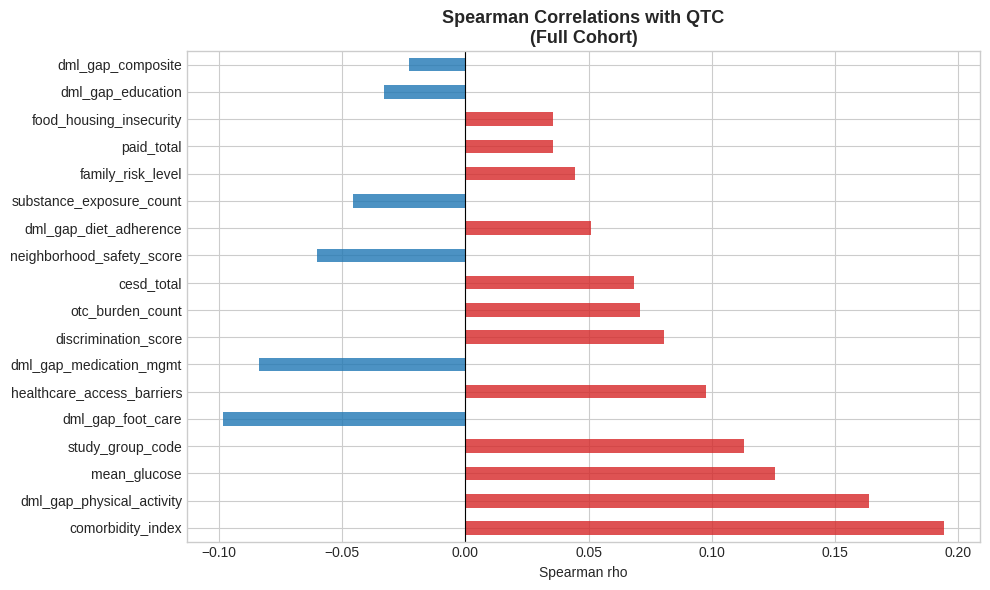

In [6]:
# ── 4b. Bar chart ─────────────────────────────────────────────────
if qtc_col and 'corr_df' in dir():
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#d62728' if v > 0 else '#1f77b4' for v in corr_df['rho']]
    corr_df['rho'].plot.barh(ax=ax, color=colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Spearman Correlations with {qtc_col.upper()}\n(Full Cohort)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Spearman rho')
    plt.tight_layout()
    plt.show()

## 5. Psychosocial Burden Tertiles × QTc

=== QTc by Psychosocial Burden Tertile ===
                    n    mean    std  median  pct_prolonged
psych_tertile                                              
Low Burden (T1)   725 428.140 26.210 426.000         17.380
Mid Burden (T2)   725 428.190 27.840 425.000         16.550
High Burden (T3)  725 432.190 29.670 430.000         21.660

Kruskal-Wallis: H=11.061  p=0.0040
Spearman (composite vs QTc): rho=0.0677  p=0.0016


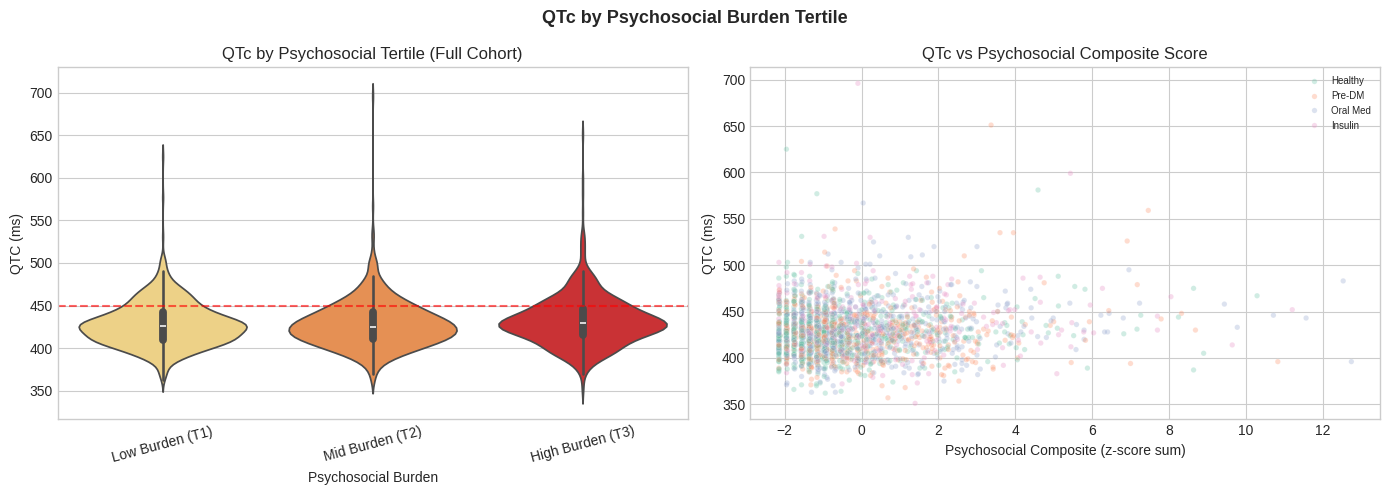

In [7]:
# ── 5. Composite psychosocial burden → tertiles → QTc ─────────────
psych_burden_cols = [c for c in ['cesd_total', 'paid_total', 'discrimination_score']
                     if c in df.columns]

if qtc_col and len(psych_burden_cols) >= 2:
    scaler = StandardScaler()
    df_sub = df[psych_burden_cols + [qtc_col, 'study_group_label']].dropna().copy()
    df_sub['psychosocial_composite'] = scaler.fit_transform(
        df_sub[psych_burden_cols]).sum(axis=1)
    df_sub['psych_tertile'] = pd.qcut(
        df_sub['psychosocial_composite'], q=3,
        labels=['Low Burden (T1)', 'Mid Burden (T2)', 'High Burden (T3)'])

    print('=== QTc by Psychosocial Burden Tertile ===')
    tertile_summary = (
        df_sub.groupby('psych_tertile', observed=True)[qtc_col]
        .agg(n='count', mean='mean', std='std', median='median',
             pct_prolonged=lambda x: (x > QTC_THRESH).mean() * 100)
        .round(2)
    )
    print(tertile_summary.to_string())

    t_groups = [df_sub[df_sub['psych_tertile'] == t][qtc_col].dropna().values
                for t in ['Low Burden (T1)', 'Mid Burden (T2)', 'High Burden (T3)']]
    t_groups = [g for g in t_groups if len(g) > 0]
    if len(t_groups) >= 2:
        h, p_t = stats.kruskal(*t_groups)
        rho_t, p_rho = stats.spearmanr(
            df_sub['psychosocial_composite'].dropna(),
            df_sub.loc[df_sub['psychosocial_composite'].notna(), qtc_col])
        print(f'\nKruskal-Wallis: H={h:.3f}  p={p_t:.4f}')
        print(f'Spearman (composite vs QTc): rho={rho_t:.4f}  p={p_rho:.4f}')

    # Violin plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'QTc by Psychosocial Burden Tertile', fontsize=13, fontweight='bold')

    sns.violinplot(data=df_sub, x='psych_tertile', y=qtc_col,
                   order=['Low Burden (T1)', 'Mid Burden (T2)', 'High Burden (T3)'],
                   palette='YlOrRd', inner='box', ax=axes[0])
    axes[0].axhline(QTC_THRESH, color='red', linestyle='--', alpha=0.6,
                    label=f'{QTC_THRESH} ms')
    axes[0].set_title('QTc by Psychosocial Tertile (Full Cohort)')
    axes[0].set_xlabel('Psychosocial Burden')
    axes[0].set_ylabel(f'{qtc_col.upper()} (ms)')
    axes[0].tick_params(axis='x', rotation=15)

    sns.scatterplot(data=df_sub, x='psychosocial_composite', y=qtc_col,
                    hue='study_group_label', hue_order=STUDY_GROUP_ORDER,
                    alpha=0.3, s=15, ax=axes[1])
    axes[1].set_title('QTc vs Psychosocial Composite Score')
    axes[1].set_xlabel('Psychosocial Composite (z-score sum)')
    axes[1].set_ylabel(f'{qtc_col.upper()} (ms)')
    axes[1].legend(fontsize=7)

    plt.tight_layout()
    plt.show()
else:
    print('QTc column or psychosocial columns not available for tertile analysis.')

## 6. Within-Group Analysis: Does Psychosocial Burden Predict QTc After Controlling for Disease Severity?

In [8]:
# ── 6. Spearman correlations within each study group ──────────────
if qtc_col:
    psych_within = [c for c in ['cesd_total', 'paid_total', 'discrimination_score',
                                 'food_housing_insecurity', 'dml_gap_composite',
                                 'comorbidity_index'] if c in df.columns]

    for grp in STUDY_GROUP_ORDER:
        sub = df[df['study_group_label'] == grp]
        rows = {}
        for col in psych_within:
            s = sub[[qtc_col, col]].dropna()
            if len(s) > 20:
                rho, p = stats.spearmanr(s[qtc_col], s[col])
                rows[col] = {'rho': round(rho, 4), 'p': round(p, 4), 'n': len(s)}
        if rows:
            print(f'\n=== {grp} (n={len(sub):,}) — correlates with {qtc_col.upper()} ===')
            t = pd.DataFrame(rows).T.sort_values('rho', key=abs, ascending=False)
            print(t.to_string())


=== Healthy (n=751) — correlates with QTC ===
                           rho     p       n
comorbidity_index        0.178 0.000 751.000
cesd_total               0.092 0.011 751.000
discrimination_score     0.078 0.033 751.000
food_housing_insecurity  0.067 0.067 751.000
dml_gap_composite        0.009 0.804 751.000
paid_total              -0.007 0.857 730.000

=== Pre-DM (n=549) — correlates with QTC ===
                           rho     p       n
comorbidity_index        0.126 0.003 549.000
discrimination_score     0.125 0.003 549.000
food_housing_insecurity  0.073 0.088 549.000
dml_gap_composite       -0.063 0.139 549.000
paid_total              -0.025 0.560 540.000
cesd_total               0.003 0.949 548.000

=== Oral Med (n=677) — correlates with QTC ===
                           rho     p       n
comorbidity_index        0.188 0.000 677.000
cesd_total               0.105 0.006 677.000
discrimination_score     0.064 0.098 677.000
paid_total               0.050 0.196 662.000
dml_

## 7. Food & Housing Insecurity × QTc

In [9]:
# ── 7a. Overall Mann-Whitney: insecure vs secure → QTc ────────────
if qtc_col and 'food_housing_insecurity' in df.columns:
    sec   = df[df['food_housing_insecurity'] == 0][qtc_col].dropna()
    insec = df[df['food_housing_insecurity'] == 1][qtc_col].dropna()
    u, p = stats.mannwhitneyu(sec, insec, alternative='two-sided')
    d    = (insec.mean() - sec.mean()) / np.sqrt((sec.std()**2 + insec.std()**2) / 2)
    print('=== Food/Housing Insecurity vs QTc (full cohort) ===')
    print(f'Secure:   mean={sec.mean():.1f} ms  SD={sec.std():.1f}  n={len(sec):,}')
    print(f'Insecure: mean={insec.mean():.1f} ms  SD={insec.std():.1f}  n={len(insec):,}')
    print(f'Mann-Whitney U={u:.0f}  p={p:.4f}  Cohen\'s d={d:+.3f}')

=== Food/Housing Insecurity vs QTc (full cohort) ===
Secure:   mean=428.4 ms  SD=26.5  n=874
Insecure: mean=430.6 ms  SD=28.9  n=1,352
Mann-Whitney U=565923  p=0.0926  Cohen's d=+0.079


=== Within-group: Secure vs Insecure QTc ===

Study Group     Secure  Insecure     diff         p  sig
------------------------------------------------------------
Healthy          425.1     429.2     +4.1    0.0669  ns
Pre-DM           424.0     428.4     +4.4    0.0878  ns
Oral Med         431.8     431.1     -0.7    0.9848  ns
Insulin          443.1     436.9     -6.2    0.0929  ns


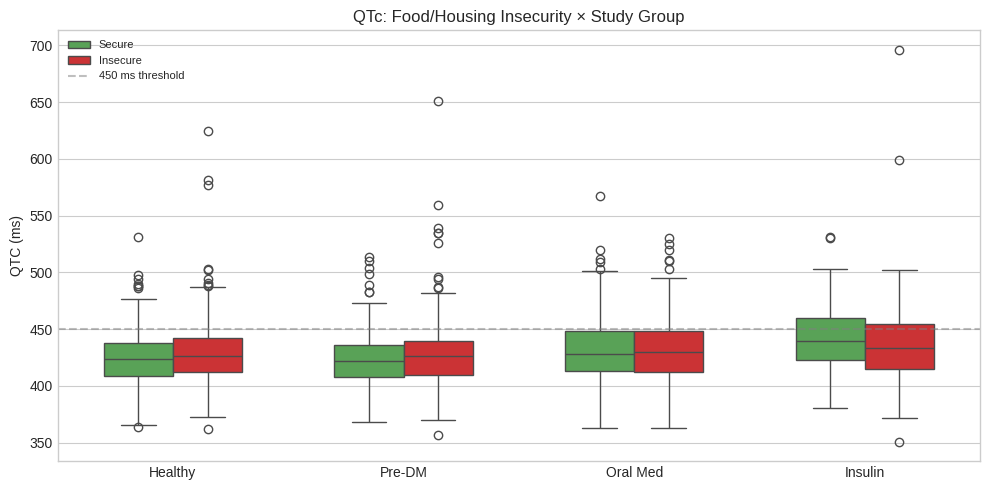

In [10]:
# ── 7b. Within-group insecurity effect on QTc ─────────────────────
if qtc_col and 'food_housing_insecurity' in df.columns:
    df['insecurity_label'] = df['food_housing_insecurity'].map(
        {0: 'Secure', 1: 'Insecure'})

    print('=== Within-group: Secure vs Insecure QTc ===\n')
    print(f'{"Study Group":<12}  {"Secure":>8}  {"Insecure":>8}  {"diff":>7}  {"p":>8}  sig')
    print('-' * 60)
    for grp in STUDY_GROUP_ORDER:
        sub = df[df['study_group_label'] == grp]
        s   = sub[sub['food_housing_insecurity'] == 0][qtc_col].dropna()
        i   = sub[sub['food_housing_insecurity'] == 1][qtc_col].dropna()
        if len(s) > 5 and len(i) > 5:
            u, p = stats.mannwhitneyu(s, i, alternative='two-sided')
            diff = i.mean() - s.mean()
            sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
            print(f'{grp:<12}  {s.mean():>8.1f}  {i.mean():>8.1f}  {diff:>+7.1f}  {p:>8.4f}  {sig}')

    # Grouped boxplot
    fig, ax = plt.subplots(figsize=(10, 5))
    pal = {'Secure': '#4daf4a', 'Insecure': '#e41a1c'}
    sub_plot = df.dropna(subset=['insecurity_label', 'study_group_label', qtc_col])
    sns.boxplot(data=sub_plot, x='study_group_label', y=qtc_col,
                hue='insecurity_label', order=STUDY_GROUP_ORDER,
                hue_order=['Secure', 'Insecure'], palette=pal, width=0.6, ax=ax)
    ax.axhline(QTC_THRESH, color='gray', linestyle='--', alpha=0.5,
               label=f'{QTC_THRESH} ms threshold')
    ax.set_title('QTc: Food/Housing Insecurity × Study Group')
    ax.set_xlabel('')
    ax.set_ylabel(f'{qtc_col.upper()} (ms)')
    ax.legend(title='', fontsize=8)
    plt.tight_layout()
    plt.show()

## 8. Comorbidity Cluster × Psychosocial Burden × QTc

In [11]:
# ── 8. 2-way: cluster × psychosocial tertile → QTc ────────────────
if qtc_col and 'comorbidity_cluster' in df.columns and 'psych_tertile' in dir():
    df2 = df.merge(
        df_sub[['person_id', 'psych_tertile']] if 'person_id' in df_sub.columns
        else df_sub[['psych_tertile']],
        left_index=True, right_index=True, how='left')

    df2['cluster_label'] = df2['comorbidity_cluster'].map(CLUSTER_MAP)
    cross = df2.groupby(['cluster_label', 'psych_tertile'], observed=True)[qtc_col] \
               .agg(n='count', mean='mean', std='std').round(2)
    print('=== QTc by Cluster × Psychosocial Tertile ===')
    print(cross.to_string())
else:
    print('Skipping 2-way interaction (run cell 5 first to generate psych_tertile).')

Skipping 2-way interaction (run cell 5 first to generate psych_tertile).


## 9. Summary Table & Export

In [12]:
# ── 9. Summary table: QTc statistics by study group ──────────────
if qtc_col:
    summary = (
        df.groupby('study_group_label', observed=True)[qtc_col]
        .agg(n='count', mean='mean', std='std', median='median',
             pct_prolonged=lambda x: (x > QTC_THRESH).mean() * 100)
        .round(2)
        .reset_index()
    )
    summary.columns = ['Study Group', 'N', f'Mean {qtc_col.upper()} (ms)', 'SD',
                       'Median', f'% > {QTC_THRESH} ms']
    print(summary.to_string(index=False))

    summary.to_csv(out_dir / '15_ecg_psychosocial_summary.csv', index=False)
    print('\nSaved 15_ecg_psychosocial_summary.csv')
else:
    print('No QTc column available — export skipped.')

Study Group   N  Mean QTC (ms)     SD  Median  % > 450 ms
    Healthy 751        427.440 26.030 425.000      15.580
     Pre-DM 549        426.680 27.640 425.000      14.030
   Oral Med 677        431.400 26.970 429.000      21.860
    Insulin 249        438.860 34.730 434.000      31.730

Saved 15_ecg_psychosocial_summary.csv


## 10. Key Findings

- **Comorbidity burden is the dominant QTc predictor** — not psychosocial factors alone: comorbidity_index shows the strongest Spearman correlation with QTc (rho=+0.194, p<0.001), followed by physical activity adherence gap (rho=+0.164), mean glucose (rho=+0.126), and study group (rho=+0.113). This pattern is consistent within every study group.

- **PAID-5 shows null QTc association** (rho=+0.036, p=0.096 ns), in sharp contrast to its strong glucose/HbA1c effect seen in NB11 and NB13. This dissociation suggests diabetes-specific distress drives poor glycemic self-management but does not independently activate cardiac electrophysiological pathways.

- **Discrimination is the only psychosocial factor with a significant independent QTc association** (rho=+0.081, p<0.001), consistent with evidence that chronic discrimination activates sympathetic stress pathways that affect cardiac repolarization. This effect is present in both Healthy (rho=+0.078*) and Pre-DM (rho=+0.125**) groups but attenuates in medicated groups where metabolic factors dominate.

- **CES-D depression has a weak but significant full-cohort association** (rho=+0.069, p=0.001). The within-group pattern shows it is only significant in Healthy (rho=+0.092**) and Oral Med (rho=+0.105**) participants, not in Pre-DM or Insulin groups, suggesting the depression-cardiac link is moderated by disease severity.

- **Food/housing insecurity shows null-to-marginal QTc association**: Full cohort Mann-Whitney p=0.0926, Cohen's d=+0.079 (negligible). Within study groups, no significant insecurity effect on QTc was detected. This mirrors the null overall glucose finding from NB12.

- **Healthcare access barriers emerge as a notable SDOH predictor of QTc** (rho=+0.098, p<0.001), suggesting structural access difficulties — not individual psychosocial burden — may be a more important cardiac risk pathway for this cohort.